<a href="https://colab.research.google.com/github/lagarda2904/Pagina/blob/main/tareas/Practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1

Desarrollar en código python una función para cada uno de los algoritmos:

*   Búsqueda lineal
*   Búsqueda binaria

Los pseudocódigos se encuentran en las diapositivas de clase.

Una vez que se tengan programadas las funciones, realizar pruebas donde a medida que la entrada de datos (N) crece, se almacene el tiempo de ejecución (en segundos o milisegundos), de tal forma que podamos graficar las curvas.

**Objetivo**: Comprobar que la complejidad que se identificó en el análisis teórico, efectivamente se ve reflejada al realizar la ejecución real de los algoritmos.




### Importamos librerías

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time

### Selection Sort

##### Definición de función

n = [10, 50, 100, 200, 400, 800, 1200]
mejor = [3.795659999923373e-05, 0.0006574979999641073, 0.0025581544000033317, 0.009715137599960144, 0.03620236700007808, 0.08935395119997339, 0.17425229880000187]
promedio = [3.4347599967077255e-05, 0.001878116600028079, 0.0030706363999797757, 0.008642311600078756, 0.1026961816000039, 0.07859988320001321, 0.18011324299995976]
peor = [3.4199800029455216e-05, 0.0006619971999953123, 0.0025385948000348434, 0.008715646399969046, 0.06617106999997305, 0.0785201403999963, 0.1829010066000592]


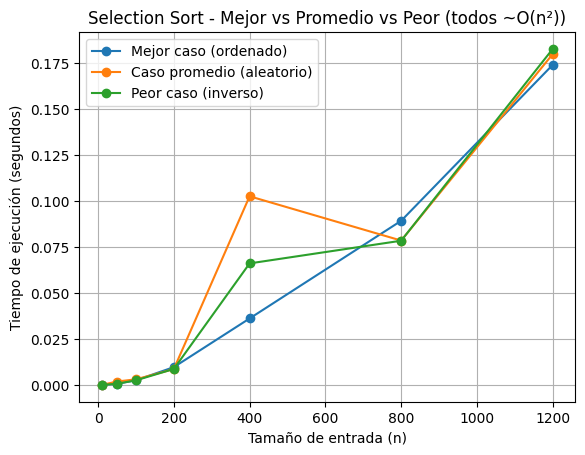

In [9]:
import numpy as np
import time
import matplotlib.pyplot as plt

def selection_sort(A):
    for i in range(len(A)):
        min_idx = i
        for j in range(i + 1, len(A)):
            if A[min_idx] > A[j]:
                min_idx = j
        A[i], A[min_idx] = A[min_idx], A[i]
    return A

# Diferentes tamaños de n
n = [10, 50, 100, 200, 400, 800, 1200]

# Para guardar tiempos
tiempos_mejor = []
tiempos_promedio = []
tiempos_peor = []

# Repeticiones para que el promedio de tiempo sea más estable
reps = 5

for size in n:
    # --- Construcción de casos ---
    A_mejor = np.arange(size)             # ya ordenado
    A_peor = np.arange(size, 0, -1)       # orden inverso


    #  Medir mejor caso
    t = 0.0
    for _ in range(reps):
        arr = A_mejor.copy()
        inicio = time.perf_counter()
        selection_sort(arr)
        fin = time.perf_counter()
        t += (fin - inicio)
    tiempos_mejor.append(t / reps)

    # Medir peor caso
    t = 0.0
    for _ in range(reps):
        arr = A_peor.copy()
        inicio = time.perf_counter()
        selection_sort(arr)
        fin = time.perf_counter()
        t += (fin - inicio)
    tiempos_peor.append(t / reps)

    # Medir caso promedio
    t = 0.0
    for _ in range(reps):
        A_prom = np.random.randint(0, 1000000, size)
        inicio = time.perf_counter()
        selection_sort(A_prom)
        fin = time.perf_counter()
        t += (fin - inicio)
    tiempos_promedio.append(t / reps)

print("n =", n)
print("mejor =", tiempos_mejor)
print("promedio =", tiempos_promedio)
print("peor =", tiempos_peor)

# Gráfica
plt.plot(n, tiempos_mejor, marker='o', label='Mejor caso (ordenado)')
plt.plot(n, tiempos_promedio, marker='o', label='Caso promedio (aleatorio)')
plt.plot(n, tiempos_peor, marker='o', label='Peor caso (inverso)')

plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Selection Sort - Mejor vs Promedio vs Peor (todos ~O(n²))")
plt.grid(True)
plt.legend()
plt.show()





##### Selection Sort peor caso

In [ ]:
# Diferentes tamaños de n
n = [1, 10, 100, 1000, 10000, 100000]

tiempos_ejecucion = []

# Para cada n
for i in n:
  # Generar un arreglo de tamaño n
  A = np.random.randint(0, 100, i)
  #print("A = ", A)

  # Definir valor objetivo: en el peor caso el valor objetivo no se encuentra en la lista
  x = -1

  # Búsqueda lineal
  inicio = time.time() # tiempo de inicio en segundos
  posicion = busqueda_lineal(A, x)
  print(f"El valor objetivo = {x} se encuentra en la posición: ", posicion)
  fin = time.time()   # tiempo de fin en segundos

  #print("Tiempo de ejecución (seg): ", fin - inicio)
  tiempos_ejecucion.append(fin - inicio)

print(tiempos_ejecucion)

##### Graficar tiempos de ejecución

In [ ]:
# Graficar tiempos de ejecución
plt.plot(n, tiempos_ejecucion, marker='o')
plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Búsqueda lineal - Peor caso O(n)")
plt.grid(True)
plt.show()

### Insertion Sort

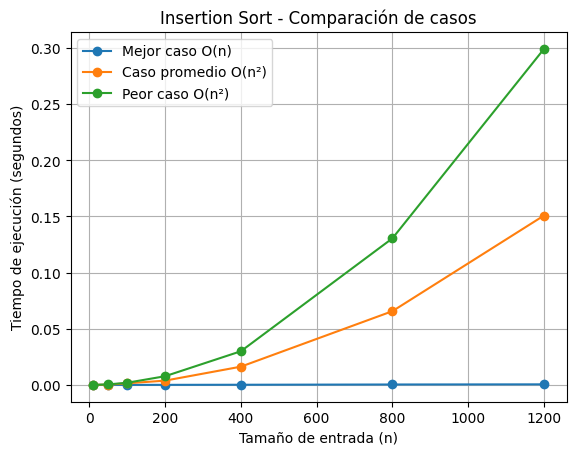

In [8]:
def insertion_sort(A):
    for i in range(1, len(A)):
        key = A[i]
        j = i - 1

        while j >= 0 and A[j] > key:
            A[j + 1] = A[j]
            j -= 1

        A[j + 1] = key

    return A


n = [10, 50, 100, 200, 400, 800, 1200]

tiempos_mejor = []
tiempos_promedio = []
tiempos_peor = []

reps = 5

for size in n:

    A_mejor = np.arange(size)          # ya ordenado
    A_peor = np.arange(size, 0, -1)    # orden inverso

    # Mejor caso
    t = 0
    for _ in range(reps):
        arr = A_mejor.copy()
        inicio = time.perf_counter()
        insertion_sort(arr)
        fin = time.perf_counter()
        t += fin - inicio
    tiempos_mejor.append(t/reps)

    # Peor caso
    t = 0
    for _ in range(reps):
        arr = A_peor.copy()
        inicio = time.perf_counter()
        insertion_sort(arr)
        fin = time.perf_counter()
        t += fin - inicio
    tiempos_peor.append(t/reps)

    # Caso promedio
    t = 0
    for _ in range(reps):
        A_prom = np.random.randint(0, 100000, size)
        inicio = time.perf_counter()
        insertion_sort(A_prom)
        fin = time.perf_counter()
        t += fin - inicio
    tiempos_promedio.append(t/reps)


plt.plot(n, tiempos_mejor, marker='o', label="Mejor caso O(n)")
plt.plot(n, tiempos_promedio, marker='o', label="Caso promedio O(n²)")
plt.plot(n, tiempos_peor, marker='o', label="Peor caso O(n²)")

plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Insertion Sort - Comparación de casos")
plt.grid(True)
plt.legend()
plt.show()




Bubble Sort

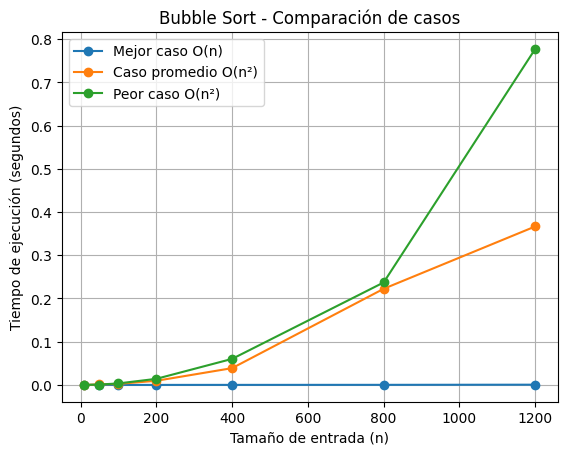

In [10]:
import numpy as np
import time
import matplotlib.pyplot as plt

def bubble_sort(A):
    n = len(A)

    for i in range(n):
        swapped = False

        for j in range(0, n - i - 1):
            if A[j] > A[j + 1]:
                A[j], A[j + 1] = A[j + 1], A[j]
                swapped = True

        if not swapped:
            break

    return A


n = [10, 50, 100, 200, 400, 800, 1200]

tiempos_mejor = []
tiempos_promedio = []
tiempos_peor = []

reps = 5

for size in n:

    A_mejor = np.arange(size)
    A_peor = np.arange(size, 0, -1)

    # Mejor caso
    t = 0
    for _ in range(reps):
        arr = A_mejor.copy()
        inicio = time.perf_counter()
        bubble_sort(arr)
        fin = time.perf_counter()
        t += fin - inicio
    tiempos_mejor.append(t/reps)

    # Peor caso
    t = 0
    for _ in range(reps):
        arr = A_peor.copy()
        inicio = time.perf_counter()
        bubble_sort(arr)
        fin = time.perf_counter()
        t += fin - inicio
    tiempos_peor.append(t/reps)

    # Caso promedio
    t = 0
    for _ in range(reps):
        A_prom = np.random.randint(0, 100000, size)
        inicio = time.perf_counter()
        bubble_sort(A_prom)
        fin = time.perf_counter()
        t += fin - inicio
    tiempos_promedio.append(t/reps)


plt.plot(n, tiempos_mejor, marker='o', label="Mejor caso O(n)")
plt.plot(n, tiempos_promedio, marker='o', label="Caso promedio O(n²)")
plt.plot(n, tiempos_peor, marker='o', label="Peor caso O(n²)")

plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Bubble Sort - Comparación de casos")
plt.grid(True)
plt.legend()
plt.show()